In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
housing = pd.read_csv(r'C:/Users/alibro/Desktop/housing_model/data/housing.csv',encoding='utf-8')
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
housing.isna().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [4]:
housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.670000e+02,567.000000,567.000000,567.000000,567.000000,567.000000
mean,4.788803e+06,5200.407407,2.955908,1.328042,1.843034,0.733686
std,1.876623e+06,2205.007468,0.765762,0.577836,0.906426,0.886477
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.375000e+06,4632.000000,3.000000,1.000000,2.000000,0.000000
75%,5.838000e+06,6420.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [5]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             567 non-null    int64
 1   area              567 non-null    int64
 2   bedrooms          567 non-null    int64
 3   bathrooms         567 non-null    int64
 4   stories           567 non-null    int64
 5   mainroad          567 non-null    str  
 6   guestroom         567 non-null    str  
 7   basement          567 non-null    str  
 8   hotwaterheating   567 non-null    str  
 9   airconditioning   567 non-null    str  
 10  parking           567 non-null    int64
 11  prefarea          567 non-null    str  
 12  furnishingstatus  567 non-null    str  
dtypes: int64(6), str(7)
memory usage: 57.7 KB


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
housing['mainroad'] = le.fit_transform(housing['mainroad'])
housing['guestroom'] = le.fit_transform(housing['guestroom'])
housing['basement'] = le.fit_transform(housing['basement'])
housing['hotwaterheating'] = le.fit_transform(housing['hotwaterheating'])
housing['airconditioning'] = le.fit_transform(housing['airconditioning'])
housing['prefarea'] = le.fit_transform(housing['prefarea'])


In [7]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             567 non-null    int64
 1   area              567 non-null    int64
 2   bedrooms          567 non-null    int64
 3   bathrooms         567 non-null    int64
 4   stories           567 non-null    int64
 5   mainroad          567 non-null    int64
 6   guestroom         567 non-null    int64
 7   basement          567 non-null    int64
 8   hotwaterheating   567 non-null    int64
 9   airconditioning   567 non-null    int64
 10  parking           567 non-null    int64
 11  prefarea          567 non-null    int64
 12  furnishingstatus  567 non-null    str  
dtypes: int64(12), str(1)
memory usage: 57.7 KB


In [8]:
housing = pd.get_dummies(
    housing,
    columns=['furnishingstatus'],
    drop_first=True
)

In [9]:
housing.duplicated().sum()

housing.drop_duplicates(inplace=True)


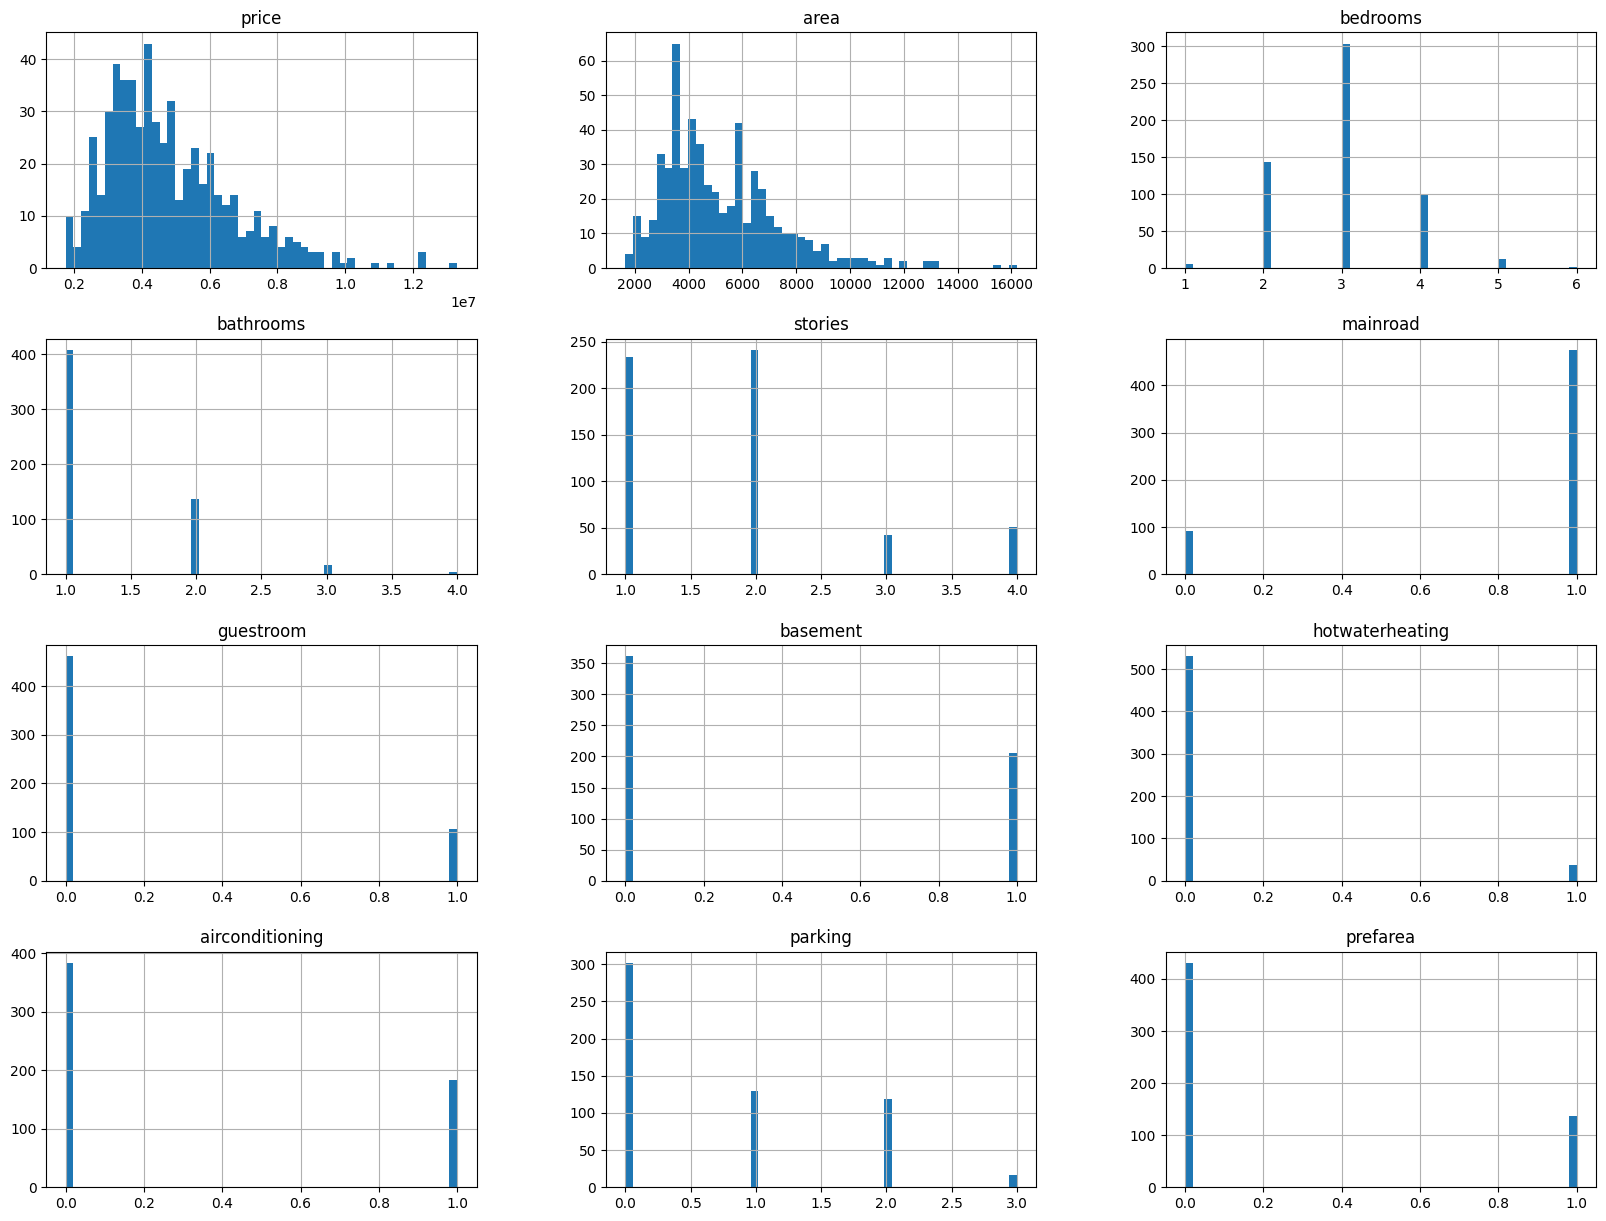

In [10]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

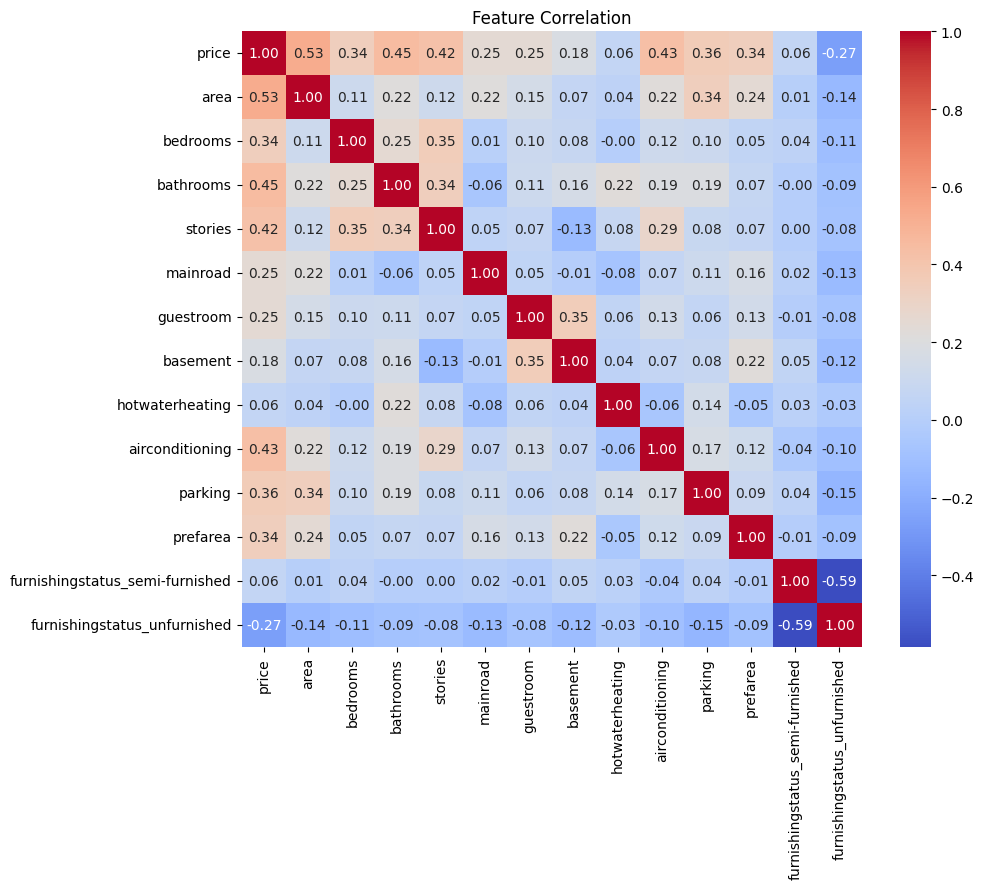

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(housing.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Feature Correlation')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = housing.drop('price', axis=1)
y = np.log(housing["price"])

model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



print(f"Mean Squared Error: {mse.__round__(2)}")
print(f"Mean Absolute Error: {mae.__round__(2)}")
print(f"R-squared: {r2.__round__(2)}")

Mean Squared Error: 0.05
Mean Absolute Error: 0.18
R-squared: 0.65


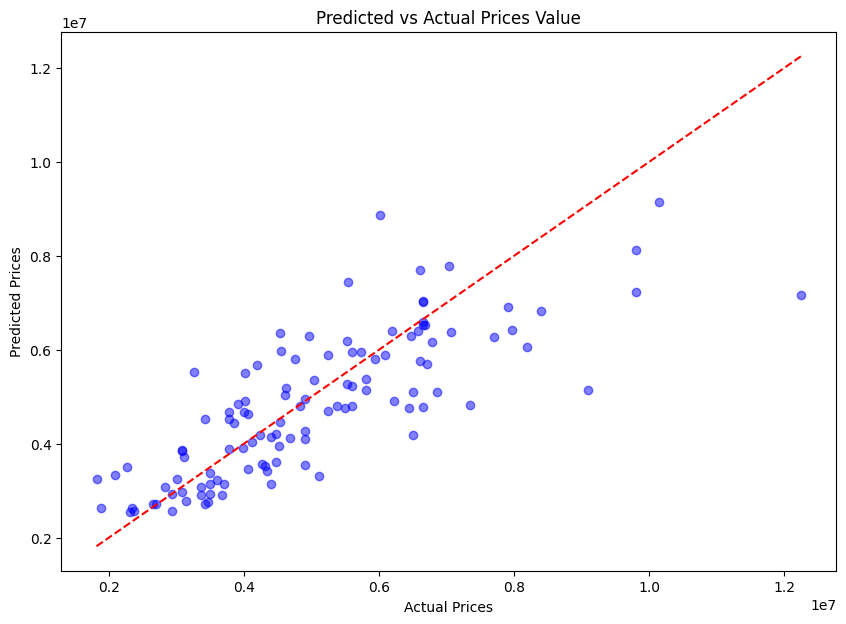

In [14]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10,7))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual Prices Value")
plt.show()
